# Exercise 1

In [ ]:
import torch

# (1)
x = torch.tensor(2.0, requires_grad=True)
y = (1 / x) * torch.exp((x - 1) ** 2)
y.backward()
print(x.grad)

tensor(2.0387)


In [21]:
# (2)
import torch

xs = torch.tensor([1.2, 2.2, 2.7, 2.8, 3.1, 3.5])
ys = torch.tensor([0, 0, 1, 0, 1, 1])

w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(-6.0, requires_grad=True)
ys_pred = torch.sigmoid(w * xs + b)
L = -torch.sum(ys * torch.log(ys_pred) + (1 - ys) * torch.log(1 - ys_pred)) / 6
L.backward()
print(w.grad)
print(b.grad)

tensor(0.6073)
tensor(0.2483)


# Exercise 2

In [ ]:
import torch

xs = torch.tensor([1.2, 2.2, 2.7, 2.8, 3.1, 3.5])
ys = torch.tensor([0, 0, 1, 0, 1, 1])

w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(-6.0, requires_grad=True)

lr = 0.1

for epoch in range(10000):
    # (1) Compute the loss and gradients
    ys_pred = torch.sigmoid(w * xs + b)
    L = -torch.sum(ys * torch.log(ys_pred) + (1 - ys) * torch.log(1 - ys_pred)) / 6
    L.backward()

    # (2) Update the parameters
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # (3) Reset the gradients to zero
    w.grad.zero_()
    b.grad.zero_()

    # (4) Print the loss and parameters
    print(f"Epoch {epoch}: loss = {L.item():.4f}, w = {w.item():.4f}, b = {b.item():.4f}")

Epoch 0: loss = 0.6290, w = 2.9393, b = -6.0248
Epoch 1: loss = 0.5872, w = 2.8823, b = -6.0481
Epoch 2: loss = 0.5506, w = 2.8291, b = -6.0699
Epoch 3: loss = 0.5188, w = 2.7800, b = -6.0901
Epoch 4: loss = 0.4918, w = 2.7349, b = -6.1087
Epoch 5: loss = 0.4690, w = 2.6938, b = -6.1257
Epoch 6: loss = 0.4501, w = 2.6567, b = -6.1413
Epoch 7: loss = 0.4347, w = 2.6233, b = -6.1554
Epoch 8: loss = 0.4222, w = 2.5934, b = -6.1682
Epoch 9: loss = 0.4123, w = 2.5669, b = -6.1798
Epoch 10: loss = 0.4044, w = 2.5436, b = -6.1902
Epoch 11: loss = 0.3982, w = 2.5230, b = -6.1995
Epoch 12: loss = 0.3934, w = 2.5050, b = -6.2079
Epoch 13: loss = 0.3898, w = 2.4894, b = -6.2154
Epoch 14: loss = 0.3869, w = 2.4758, b = -6.2222
Epoch 15: loss = 0.3848, w = 2.4641, b = -6.2284
Epoch 16: loss = 0.3831, w = 2.4539, b = -6.2339
Epoch 17: loss = 0.3819, w = 2.4452, b = -6.2389
Epoch 18: loss = 0.3809, w = 2.4378, b = -6.2434
Epoch 19: loss = 0.3802, w = 2.4315, b = -6.2476
Epoch 20: loss = 0.3797, w = 2

# Exercise 3

In [ ]:
X = torch.tensor([[1.0, 1.0], [3.0, 3.0], [5.0, 5.0], [2.0, 4.0], [5.0, 3.0], [2.0, 2.0]])
ys = torch.tensor([1.0, 4.0, 2.0, 4.0, 3.0, 3.0])

class MLP(torch.nn.Module):
    def __init__(self, x_dim, h_dim, y_dim):
        super(MLP, self).__init__()
        self.linear1 = torch.nn.Linear(x_dim, h_dim)
        self.linear2 = torch.nn.Linear(h_dim, y_dim)

    def forward(self, x):
        h = torch.relu(self.linear1(x))
        y_pred = self.linear2(h)
        return y_pred

mlp = MLP(2, 2, 1)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(mlp.parameters(), lr=0.001)

for epoch in range(25000):
    # (1) Compute the loss and gradients
    ys_pred = mlp(X)
    L = loss_fn(ys_pred, ys.view(-1, 1))
    L.backward()

    # (2) Update the parameters
    optimizer.step()
    
    # (3) Reset the gradients to zero
    optimizer.zero_grad()
    
    # (4) Print the loss
    print("Epoch {0}: Loss {1:.10f}".format(epoch, L.item()))

# Print the parameters
for name, param in mlp.named_parameters():
    print(name, param.data)

Epoch 24999: Loss 0.0002872569
linear1.weight tensor([[-0.2102, -0.2048],
        [-0.3114, -0.7370]])
linear1.bias tensor([2.3900, 2.7939])
linear2.weight tensor([[ 2.3507, -2.8150]])
linear2.bias tensor([1.2863])


(100, 2) (1, 2) (1,)


/var/folders/13/s3wpmz292nv1cz1vvrvmg4t00000gn/T/ipykernel_93383/4294439618.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x1range = np.arange(min(X[:,0])-step, max(X[:,0]+step), step)
/var/folders/13/s3wpmz292nv1cz1vvrvmg4t00000gn/T/ipykernel_93383/4294439618.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x2range = np.arange(min(X[:,1])-step, max(X[:,1]+step), step)


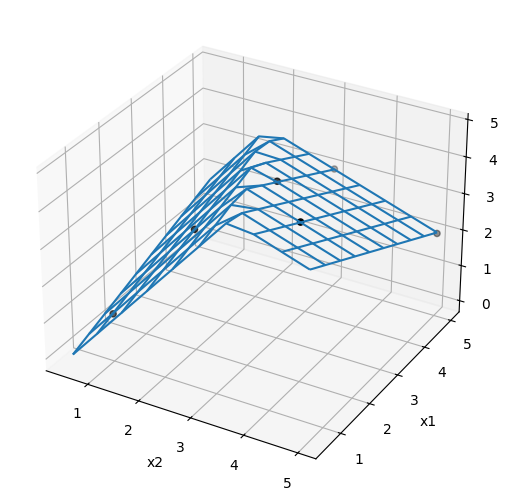

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

W1 = mlp.linear1.weight.detach().numpy()
b1 = mlp.linear1.bias.detach().numpy()
W2 = mlp.linear2.weight.detach().numpy()
b2 = mlp.linear2.bias.detach().numpy()

def relu(x):
    return np.where(x >= 0, x, 0.0)

step = 0.5
x1range = np.arange(min(X[:,0])-step, max(X[:,0]+step), step)
x2range = np.arange(min(X[:,1])-step, max(X[:,1]+step), step)
X1, X2 = np.meshgrid(x1range, x2range)
X12 = np.c_[np.ravel(X1), np.ravel(X2)]
H12 = relu(np.matmul(X12, W1.transpose()) + b1)
print(H12.shape, W2.shape, b2.shape)
Y12= np.matmul(H12, W2.transpose()) + b2

fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)
ax.set_xlabel("x2")
ax.set_ylabel("x1")
ax.set_zlabel("y")
surf = ax.plot_wireframe(X2, X1, Y12.reshape(X1.shape))

ax.scatter(X[:,1], X[:,0], ys, marker='o', c='black')
plt.show()